In [196]:
import numpy as np
from matplotlib import pyplot as plt
import random as rnd

Suppose the field is a 100m x 100m space, with 8 patches of random dimension from 3% to 10% diameter

A patch is defined as (y, x, h, w)
All units are in percentage of total dimension

Assuming a 10 gsd image, the image dimensions will be 1000 x 1000

In [197]:
def visualize_orthophoto(orthophoto):
    plt.imshow(orthophoto)
    plt.axis('off')
    plt.show()

def visualize_path(path, orthophoto):
    #Generate orthophoto in grayscale with green coloured path as a set of lines
    orthophoto_rgb = np.stack((orthophoto,)*3, axis=-1)
    for i in range(len(path)-1):
        y1, x1 = path[i]
        y2, x2 = path[i+1]
        plt.plot([x1, x2], [y1, y2], color='green', linewidth=2)
    plt.imshow(orthophoto_rgb)
    plt.axis('off')
    plt.show()

def visualize_motor_toggle(motor_toggle_path, orthophoto):
    orthophoto_rgb = np.stack((orthophoto,)*3, axis=-1)
    motor_toggle = 0
    motor_color = 'green'
    
    for i in range(len(motor_toggle_path) - 1):
        y1, x1 = motor_toggle_path[i].get('y', 0), motor_toggle_path[i].get('x', 0)
        y2, x2 = motor_toggle_path[i + 1].get('y', 0), motor_toggle_path[i + 1].get('x', 0)
        
        toggle = motor_toggle_path[i].get('toggle', None)
        if toggle is not None:
            motor_toggle = toggle
            motor_color = 'red' if motor_toggle else 'green'
        
        plt.plot([x1, x2], [y1, y2], color=motor_color, linewidth=2)
    
    plt.imshow(orthophoto_rgb)
    plt.axis('off')
    plt.show()

In [198]:
PATCH_COUNT = 8
PATCH_HEIGHT_RANGE = (5, 13)
PATCH_WIDTH_RANGE = (5, 13)

ORTHOPHOTO_HEIGHT = 100 # m
ORTHOPHOTO_WIDTH = 100 # m
ORTHOPHOTO_GSD = 10 # cm/px

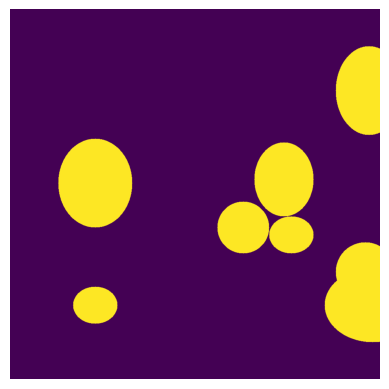

In [199]:
patches = [(rnd.randint(0, 100), rnd.randint(0, 100), rnd.randint(*PATCH_HEIGHT_RANGE), rnd.randint(*PATCH_WIDTH_RANGE)) for _ in range(PATCH_COUNT)]

def add_patch(arr, patch, value=1):
    y, x, h, w = patch
    H, W = arr.shape
    
    y, x, h, w = int(y * H / 100), int(x * W / 100), int(h * H / 100), int(w * W / 100)
    Y, X = np.ogrid[:H, :W]
    
    mask = ((Y - y)**2 / h**2) + ((X - x)**2 / w**2) <= 1
    
    arr[mask] = value

orthophoto = np.zeros((int(ORTHOPHOTO_HEIGHT * 100 / ORTHOPHOTO_GSD), int(ORTHOPHOTO_WIDTH * 100 / ORTHOPHOTO_GSD)))
for patch in patches:
    add_patch(orthophoto, patch)
    
visualize_orthophoto(orthophoto)


[(25.0, 25.0), (75.0, 25.0), (125.0, 25.0), (175.0, 25.0), (225.0, 25.0), (275.0, 25.0), (325.0, 25.0), (375.0, 25.0), (425.0, 25.0), (475.0, 25.0), (525.0, 25.0), (575.0, 25.0), (625.0, 25.0), (675.0, 25.0), (725.0, 25.0), (775.0, 25.0), (825.0, 25.0), (875.0, 25.0), (925.0, 25.0), (975.0, 25.0), (975.0, 75.0), (925.0, 75.0), (875.0, 75.0), (825.0, 75.0), (775.0, 75.0), (725.0, 75.0), (675.0, 75.0), (625.0, 75.0), (575.0, 75.0), (525.0, 75.0), (475.0, 75.0), (425.0, 75.0), (375.0, 75.0), (325.0, 75.0), (275.0, 75.0), (225.0, 75.0), (175.0, 75.0), (125.0, 75.0), (75.0, 75.0), (25.0, 75.0), (25.0, 125.0), (75.0, 125.0), (125.0, 125.0), (175.0, 125.0), (225.0, 125.0), (275.0, 125.0), (325.0, 125.0), (375.0, 125.0), (425.0, 125.0), (475.0, 125.0), (525.0, 125.0), (575.0, 125.0), (625.0, 125.0), (675.0, 125.0), (725.0, 125.0), (775.0, 125.0), (825.0, 125.0), (875.0, 125.0), (925.0, 125.0), (975.0, 125.0), (975.0, 175.0), (925.0, 175.0), (875.0, 175.0), (825.0, 175.0), (775.0, 175.0), (725.

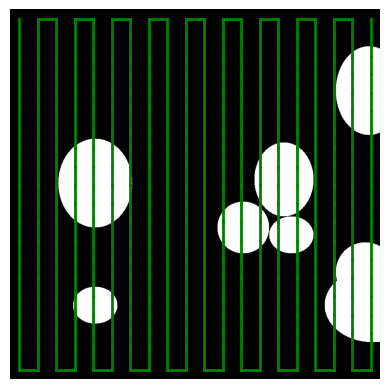

In [200]:
path = []
pos = (0, 0)    # y, x
heading = 1     # Start facing down
STEP_SIZE = 5   #m

# Generate a lawnmower path and save the coordinates
while pos[0] < ORTHOPHOTO_HEIGHT and pos[1] < ORTHOPHOTO_WIDTH:
    path.append(pos)
    
    if heading == 1: # moving down
        if pos[0] + STEP_SIZE < ORTHOPHOTO_HEIGHT:
            pos = (pos[0] + STEP_SIZE, pos[1])
        else:
            pos = (pos[0], pos[1] + STEP_SIZE)
            heading = -1
    elif heading == -1: # moving up
        if pos[0] - STEP_SIZE >= 0:
            pos = (pos[0] - STEP_SIZE, pos[1])
        else:
            pos = (pos[0], pos[1] + STEP_SIZE)
            heading = 1

path_scaled = [((y + 2.5) * 100 / ORTHOPHOTO_GSD, (x + 2.5) * 100 / ORTHOPHOTO_GSD) for y, x in path]
print(path_scaled)
visualize_path(path_scaled, orthophoto)

Now we keep track of a Toggle variable as we traverse this path, we note the toggles and the points of toggle

[{'x': 25, 'y': 25}, {'x': 25, 'y': 75}, {'x': 25, 'y': 125}, {'x': 25, 'y': 175}, {'x': 25, 'y': 225}, {'x': 25, 'y': 275}, {'x': 25, 'y': 325}, {'x': 25, 'y': 375}, {'x': 25, 'y': 425}, {'x': 25, 'y': 475}, {'x': 25, 'y': 525}, {'x': 25, 'y': 575}, {'x': 25, 'y': 625}, {'x': 25, 'y': 675}, {'x': 25, 'y': 725}, {'x': 25, 'y': 775}, {'x': 25, 'y': 825}, {'x': 25, 'y': 875}, {'x': 25, 'y': 925}, {'x': 25, 'y': 975}, {'x': 75, 'y': 975}, {'x': 75, 'y': 925}, {'x': 75, 'y': 875}, {'x': 75, 'y': 825}, {'x': 75, 'y': 775}, {'x': 75, 'y': 725}, {'x': 75, 'y': 675}, {'x': 75, 'y': 625}, {'x': 75, 'y': 575}, {'x': 75, 'y': 525}, {'x': 75, 'y': 475}, {'x': 75, 'y': 425}, {'x': 75, 'y': 375}, {'x': 75, 'y': 325}, {'x': 75, 'y': 275}, {'x': 75, 'y': 225}, {'x': 75, 'y': 175}, {'x': 75, 'y': 125}, {'x': 75, 'y': 75}, {'x': 75, 'y': 25}, {'x': 125, 'y': 25}, {'x': 125, 'y': 75}, {'x': 125, 'y': 125}, {'x': 125, 'y': 175}, {'x': 125, 'y': 225}, {'x': 125, 'y': 275}, {'x': 125, 'y': 325}, {'x': 125, 

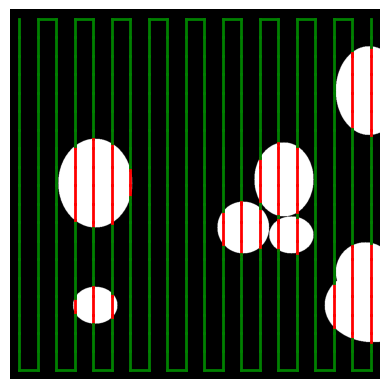

In [201]:
class Toggle:
    OFF = 0
    ON = 1

class PathPoint:
    
    toggle = None
    x, y = None, None
    
    def __init__(self, y, x, toggle = None):
        self.x = x
        self.y = y
        self.Toggle = toggle
    
    def to_dict(self):
        if self.Toggle is None:
            return {
                'x': int(self.x),
                'y': int(self.y)
            }
        else:
            return {
                'x': int(self.x),
                'y': int(self.y),
                'toggle': self.Toggle
            }

def line_pixels_array(y1, x1, y2, x2):
    n = max(abs(x2 - x1), abs(y2 - y1))
    t = np.linspace(0, 1, n+1)
    xs = (x1 + (x2 - x1) * t).astype(int)
    ys = (y1 + (y2 - y1) * t).astype(int)
    return ys, xs

motor_state = Toggle.OFF
motor_toggle_points = []
for i, pathpoint in enumerate(path_scaled):
      
    motor_toggle_points.append(PathPoint(pathpoint[0], pathpoint[1]).to_dict())
    
    #Skip motor toggling logic for the final waypoint since it is not a toggle point
    if i == len(path_scaled) - 1:
        continue
    
    #Toggle motor to ON at every posedge of patch and to OFF at every negedge of patch
    line_to_next_point = line_pixels_array(int(pathpoint[0]), int(pathpoint[1]), int(path_scaled[i+1][0]), int(path_scaled[i+1][1]))
    
    for y, x in zip(*line_to_next_point):
        if orthophoto[y, x] == 1 and motor_state == Toggle.OFF:
            motor_state = Toggle.ON
            motor_toggle_points.append(PathPoint(y, x, Toggle.ON).to_dict())
        elif orthophoto[y, x] == 0 and motor_state == Toggle.ON:
            motor_state = Toggle.OFF
            motor_toggle_points.append(PathPoint(y, x, Toggle.OFF).to_dict())

print(motor_toggle_points)
visualize_motor_toggle(motor_toggle_points, orthophoto)

In [202]:
import json 

with open('motor_toggle_points.json', 'w') as f:
    out = {}
    out["gsd"] = ORTHOPHOTO_GSD
    out["height_m"] = ORTHOPHOTO_HEIGHT
    out["width_m"] = ORTHOPHOTO_WIDTH
    out["path"] = motor_toggle_points
    json.dump(out, f, indent=4)